# Imports

In [4]:
adata = ad.read_h5ad('/vol/projects/jnourisa/datasets/data1_sc_M.h5ad', backed='r')
adata.obs['sex'].value_counts()

sex
M    513359
Name: count, dtype: int64

save here
/vol/projects/jnourisa

## From Ali
Processing for 3.2 M cells:
/vol/projects/CIIM/Healthy_Single_Cell_Data/scripts/processing.py

You can find some info of how they preprocessed the pbmc_ageing data here:
https://github.com/teresho4/scRNA-seq_atlas_Hs_PBMC_aging



In [1]:
%reload_ext autoreload
%autoreload 2
import seaborn as sns
import anndata as ad 
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
from scipy.sparse import csr_matrix
import sys
import os
from tqdm import tqdm

sys.path.insert(0, '../')
from task_grn_inference.src.utils.util import colors_blind
from task_grn_inference.src.exp_analysis.helper import Exp_analysis, plot_interactions, create_interaction_info, create_interaction_df, jaccard_similarity_net, cosine_similarity_net, calculate_feature_distance, plot_cumulative_density
from task_grn_inference.src.utils.util import basic_qc, read_gmt

from src.helper_plots import exp_plots
from src.helper import major_cell_types, cell_type_mapping

ImportError: cannot import name 'colors_blind' from 'src.helper' (/home/jnourisa/projs/ongoing/ciim/notebooks/../src/helper.py)

# create test data

In [14]:
adata = ad.read_h5ad('/vol/projects/jnourisa/datasets/data7_sc.h5ad', backed='r')
adata = adata[adata.obs['donor_id'].isin(adata.obs.groupby('donor_id').size().sort_values()[0:10].index)]

In [16]:
adata = adata.to_memory()

In [17]:
adata.write('/vol/projects/jnourisa/datasets/data7_sc_test.h5ad')

In [2]:
adata = ad.read_h5ad('/vol/projects/CIIM/Healthy_Single_Cell_Data/output/processed_external_data/data10_annotated.h5ad')


AnnData object with n_obs × n_vars = 538266 × 20013
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donor_id', 'age', 'sex', 'batch_info', 'ct_major_published', 'ct_sub_published', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'Major_CT', 'Sub_CT'
    var: 'features', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'n_counts'
    uns: 'log1p', 'neighbors', 'over_clustering', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'lognorm'
    obsp: 'connectivities', 'distances'

In [6]:
X_norm = sc.pp.normalize_total(adata, target_sum=1e4, layers = ['counts'], inplace=False)['X']
X_norm = np.log1p(X_norm)
adata.layers['lognorm'] = csr_matrix(X_norm)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat_v3', n_bins=20, layer='counts')
sc.pp.pca(adata, n_comps=50, use_highly_variable=True, svd_solver='arpack', layer='lognorm')
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=50)
sc.tl.umap(adata)

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:188: FutureWarning: The `layers` argument is deprecated. Instead, specify individual layers to normalize with `layer`.
  warn(
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:439: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


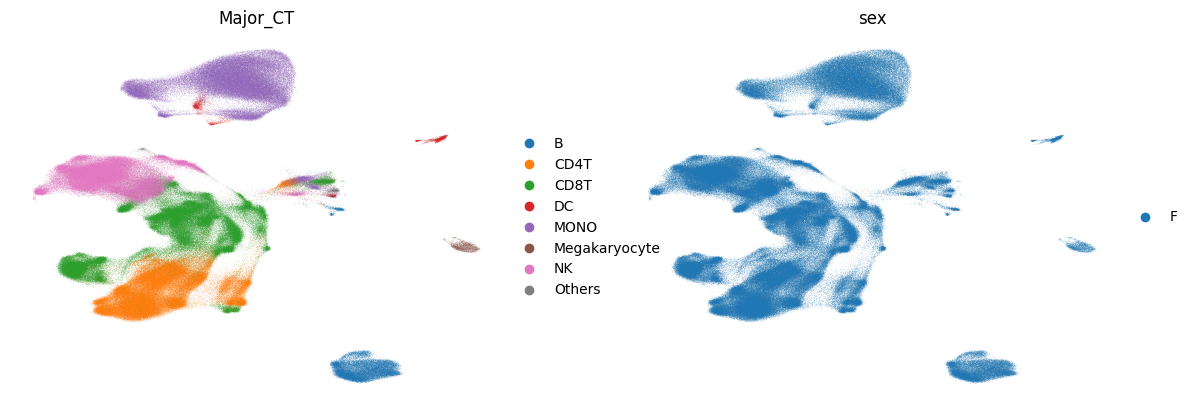

In [9]:
sc.pl.umap(adata, color=["Major_CT", 'sex'], frameon=False)


In [13]:
adata.obs['age'].astype(int).min()

0

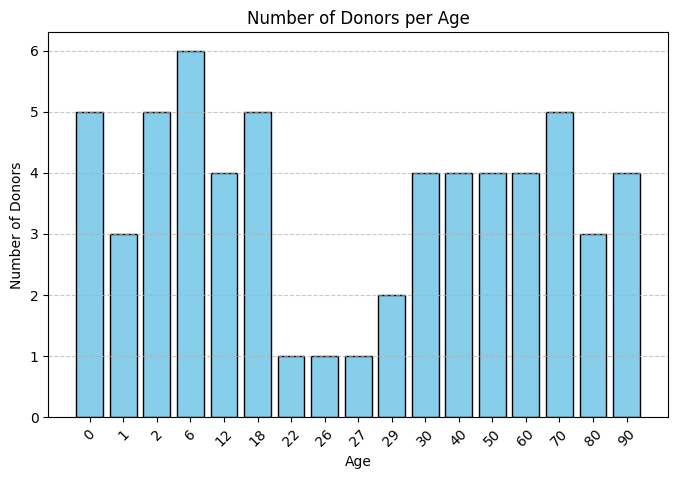

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Count unique donors per age
donor_counts = adata.obs.groupby("age")["donor_id"].nunique().reset_index()

# Plot
plt.figure(figsize=(8, 5))
plt.bar(donor_counts["age"], donor_counts["donor_id"], color="skyblue", edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Number of Donors")
plt.title("Number of Donors per Age")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# All datasets overview

In [ ]:
adata = ad.read_h5ad("/vol/projects/CIIM/Healthy_Single_Cell_Data/output/processed_data/processed_data.h5ad", backed='r')
obs = adata.obs.copy()
unique_datasets = adata.obs['orig.ident'].unique()
color_palette = sns.color_palette("tab10", len(unique_datasets))
dataset_color_mapping = {dataset: color_palette[i] for i, dataset in enumerate(unique_datasets)}


In [123]:
adata


AnnData object with n_obs × n_vars = 3265222 × 12154 backed at '/vol/projects/CIIM/Healthy_Single_Cell_Data/output/processed_data/processed_data.h5ad'
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donor_id', 'age', 'sex', 'batch_info', 'ct_major_published', 'dataset', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden_res0_5', 'leiden_res1', 'predicted_labels', 'majority_voting', 'conf_score', 'Major_CT', 'Sub_CT', 'Celltypist_Low', 'conf_score_Low', 'over_clustering'
    var: 'features', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'n_counts', 'mean', 'std'
    uns: 'Celltypist_Low_colors', 'Major_CT_colors', 'Sub_CT_colors', 'dendrogram_Celltypist_Low', 'dendrogram_Major_CT', 'dendrogram_Sub_CT', 'leiden_res0_5', 'leiden_res1', 'log1p', 'majority_voting_colors', 'neighbors', 'over_clustering', 'pca', 'umap', 'orig.ident_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'

In [127]:
from src.helper_dataset import formatize_obs_all
obs = formatize_obs_all(adata.obs)


## Cell count of donors

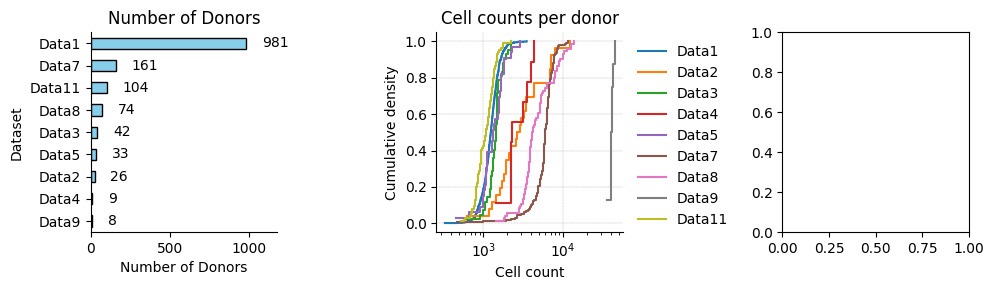

In [106]:

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

# - donor counts
ax = axes[0]
donor_counts = obs.groupby('orig.ident')['donor_id'].nunique().sort_values()
donor_counts.plot(kind='barh', color='skyblue', edgecolor='black', ax=ax)

# Add labels to the end of the bars
for index, value in enumerate(donor_counts):
    ax.text(value+100, index, f"{value}", va='center', ha='left')  # Align to the left of the bar

# Customize the axes
ax.set_ylabel("Dataset")
ax.set_xlabel("Number of Donors")
ax.set_title("Number of Donors")
ax.margins(x=0.2)
ax.spines[['top', 'right']].set_visible(False)

# - distribution of cell counts per donor
ax = axes[1]
for dataset in unique_datasets:
    obs_dataset = obs[obs['orig.ident'] == dataset].copy()
    obs_dataset['donor_id'] = obs_dataset['donor_id'].astype('str')
    counts = obs_dataset.groupby('donor_id').size().sort_values(ascending=False)
    plot_cumulative_density(counts, ax=ax, label=dataset, color=dataset_color_mapping[dataset])
    ax.set_xlabel('Cell count')
    ax.set_ylabel('Cumulative density')
    ax.set_xscale('log')
ax.set_title("Cell counts per donor")
ax.legend(loc=(1.05, 0), frameon=False)

plt.tight_layout()

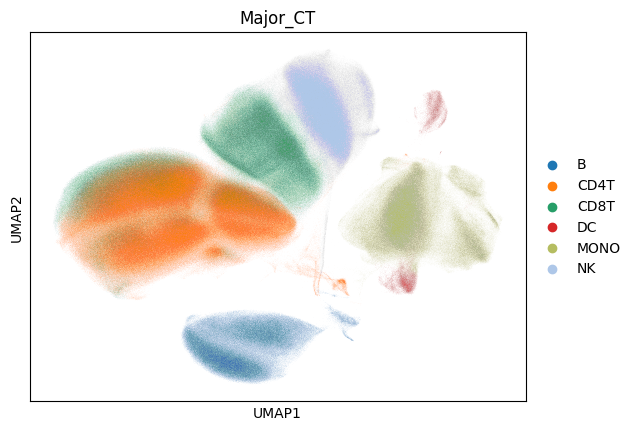

In [ ]:
sc.pl.umap(adata[adata.obs['Major_CT'].isin(major_cell_types_ali)], color='Major_CT')

# datasets overview

## Expression patterns: pseudobulked

In [7]:
def analyse_umap(adata):
    # adata = adata[adata.obs['cell_type'].isin(major_cell_types), :]
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    # sc.pp.highly_variable_genes(adata, n_top_genes=2000)

    sc.pp.pca(adata, use_highly_variable=False)  
    sc.pp.neighbors(adata, n_neighbors=15)  
    sc.tl.umap(adata)  
    return adata
adata_all_bulk = analyse_umap(adata_all_bulk)

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:385: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


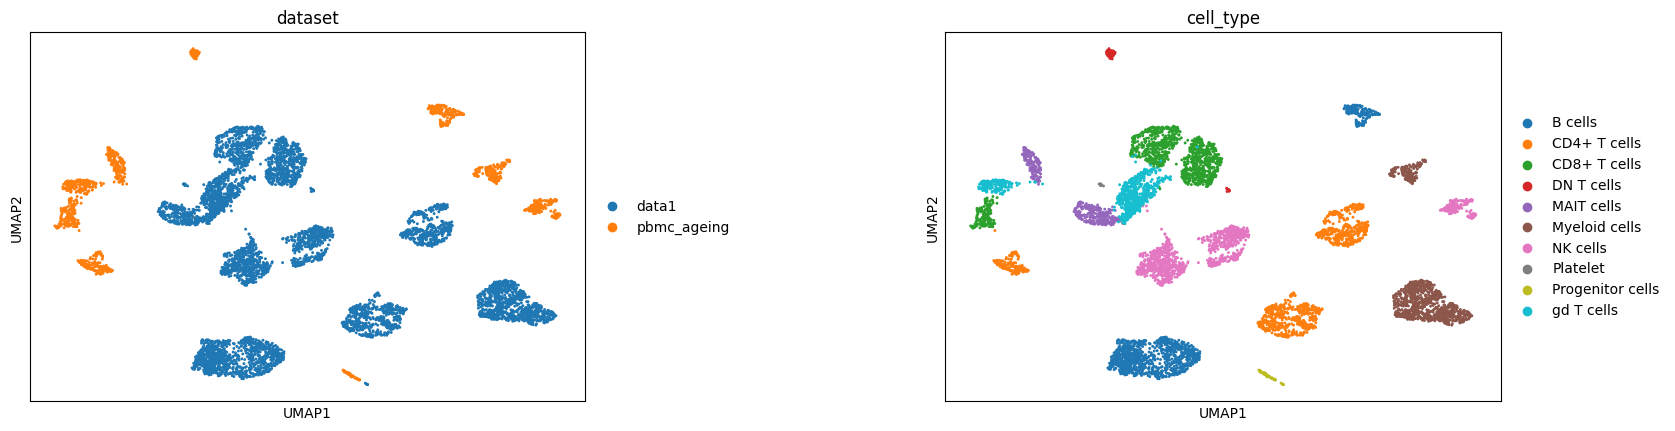

In [8]:
sc.pl.umap(adata_all_bulk, color=['dataset', 'cell_type'], wspace=.5)

In [9]:
adata_all_bulk.write('input/adata_all_bulk.h5ad')

In [ ]:
aa

# UMAP

In [3]:
from src.helper import  major_cell_types


In [13]:
dataset = 'pbmc_ageing'

In [14]:
if True:
    adata = ad.read_h5ad(f'input/{dataset}.h5ad')
    adata = adata[adata.obs['cell_type'].isin(major_cell_types), :]
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)

    sc.pp.pca(adata, use_highly_variable=True)  
    sc.pp.neighbors(adata, n_neighbors=15)  
    sc.tl.umap(adata)  
    adata.write(f'input/{dataset}_umap.h5ad')
else:
    adata = ad.read_h5ad(f'input/{dataset}_umap.h5ad')

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:385: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


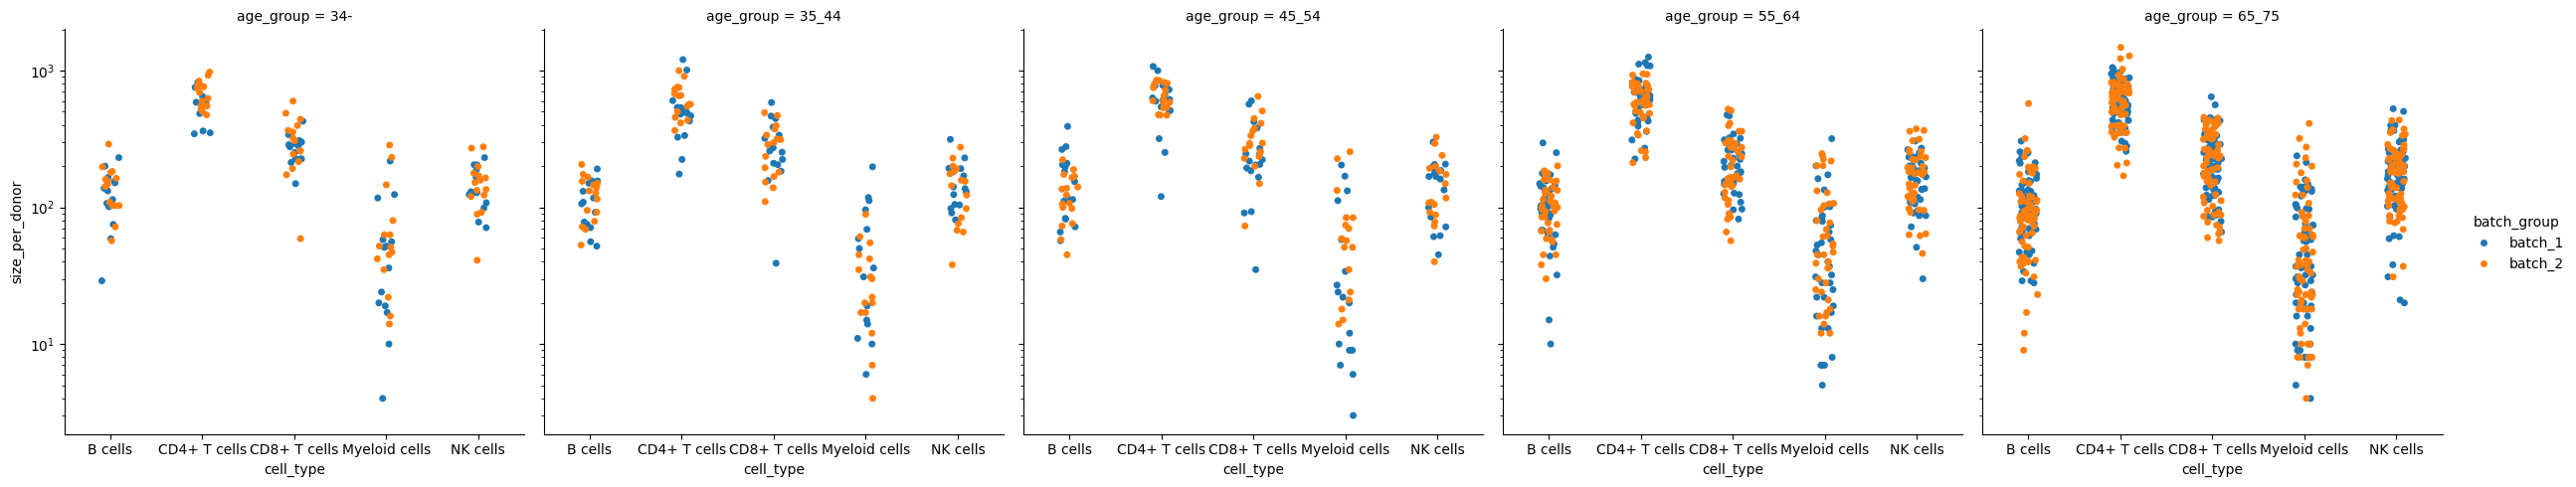

In [25]:
size_per_donor = adata.obs.groupby(['age_group', 'cell_type', 'batch_group','donor_id']).size().reset_index(name='size_per_donor')
g= sns.catplot(size_per_donor, x='cell_type', y='size_per_donor', col='age_group', hue='batch_group', kind='strip')
g.set(yscale="log")

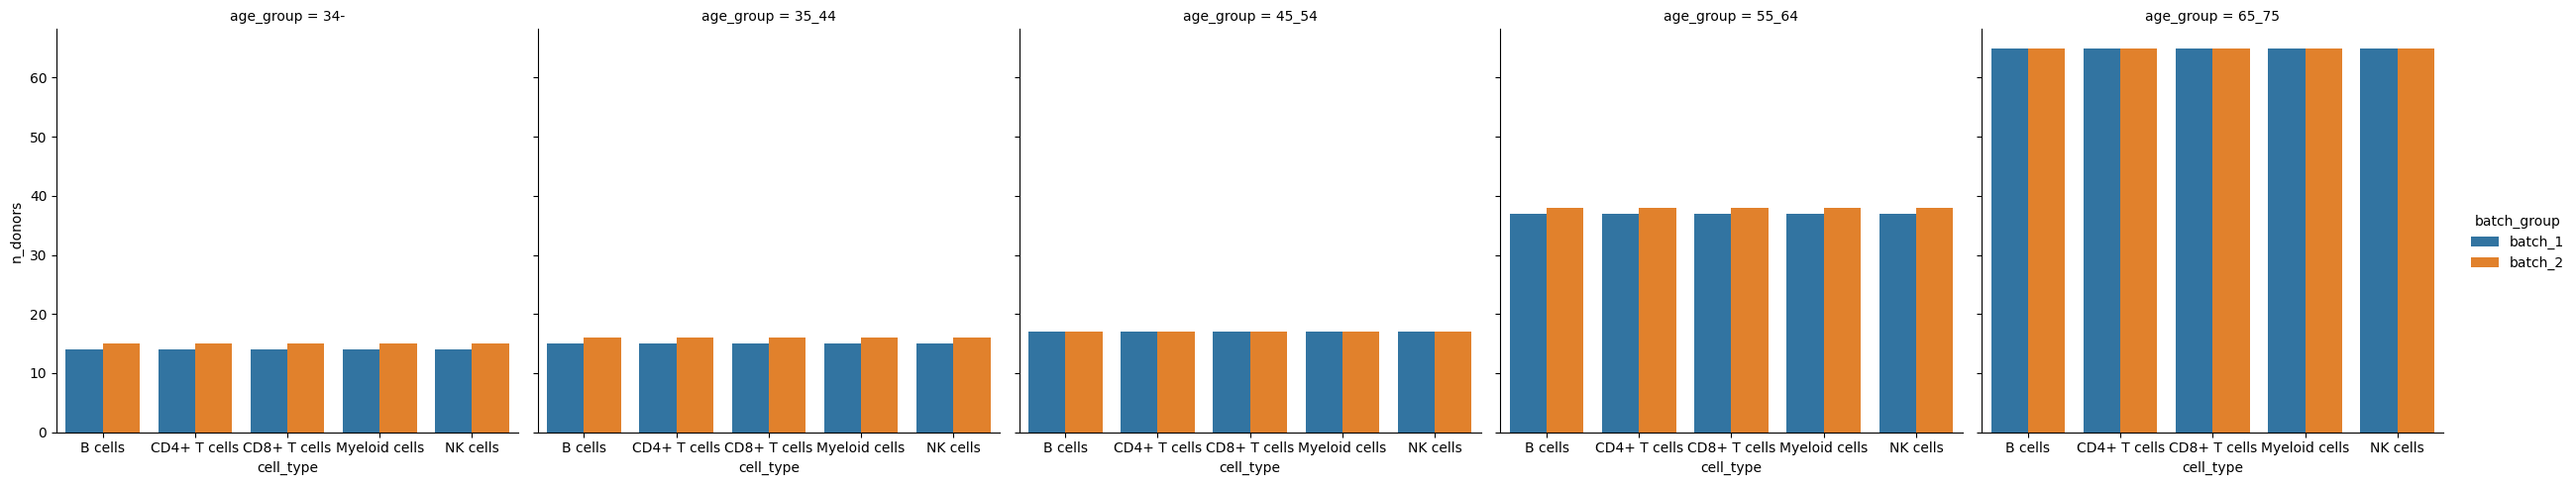

In [26]:
n_donors = adata.obs.groupby(['age_group', 'cell_type', 'batch_group'])['donor_id'].nunique().reset_index(name='n_donors')
sns.catplot(n_donors, x='cell_type', y='n_donors', col='age_group', hue='batch_group', kind='bar')

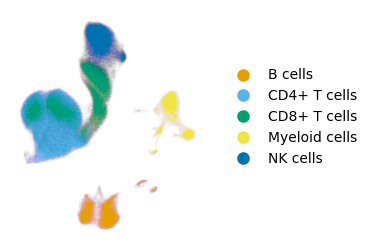

In [12]:
from src.helper import cell_type_palette

def plot_umap(adata, color='', palette=None, ax=None, X_label='X_umap', on_data=False,
              bbox_to_anchor=None, legend=True, legend_title='', **kwrds):
    latent = adata.obsm[X_label]
    var_unique_sorted = sorted(adata.obs[color].unique())
    legend_handles = []
    
    for i_group, group in enumerate(var_unique_sorted):
        mask = adata.obs[color] == group
        sub_data = latent[mask]
        if palette is None:
            c = None 
        else:
            c = palette[group]
        # Plot scatter points
        scatter = ax.scatter(sub_data[:, 0], sub_data[:, 1], label=group, c=c, **kwrds)
        if palette is None:
            solid_color = scatter.get_facecolor()[0]
        else:
            solid_color = c
        # plot legend
        legend_handles.append(plt.Line2D([0], [0], linestyle='none', marker='o', markersize=8, color=solid_color))
        if on_data:
            mean_x = np.mean(sub_data[:, 0])
            mean_y = np.mean(sub_data[:, 1])
            ax.text(mean_x, mean_y, group, fontsize=9, ha='center', va='top', color='black', weight='bold')
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])

    if legend and not on_data:
        legend = ax.legend(handles=legend_handles, labels=var_unique_sorted, loc=(1.1,.3), 
                           bbox_to_anchor=bbox_to_anchor, frameon=False, title=legend_title, 
                           title_fontproperties={'weight': 'bold', 'size': 9})
        legend.get_title().set_ha('left')
        legend._legend_box.align = "left" 
    

# Example usage
fig, ax = plt.subplots(1, 1, figsize=(2.5, 3))
plot_umap(adata, color='cell_type', ax=ax, s=.4, alpha=0.005, palette=cell_type_palette)  
# plot_umap(adata[adata.obs['batch_group']=='batch_2'], color='batch_group', ax=ax, s=1, alpha=0.3)  
# plot_umap(adata, color='donor_id', ax=ax, s=1, alpha=0.3)  
plt.savefig(f'output/figs/umap_{dataset}.png', dpi=300, bbox_inches='tight')


In [2]:
adata = ad.read_h5ad('input/data1_male.h5ad')

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [3]:
adata

AnnData object with n_obs × n_vars = 0 × 0
    obs: 'batch_group', 'donor_id', 'age', 'cell_type', 'sex', 'age_donor', 'age_group', 'batch', 'dataset'
    var: 'features'